In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../../lib"))
import util

# Introduction
We investigate two variations on the objective. The first is simply a rewriting of the loss. In the original iVAE, they split the loss into 3 terms (3 log likelihood terms), unlike the standard two-term reconstruction and KL loss split. The second variation is a bit more nuanced and pertains to how the posterior is defined. Original iVAE directly computes the posterior $q(z|x,u)$ using an MLP that depends on both $x$ and $u$. But we can also leverage the prior information here to define the posterior as $$q(z|x,u) \propto q(z|x) p(z|u).$$

# Setup

### MLP network

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, mu_flag=True, var_flag=True, **kwargs):
        super().__init__()
        self.mu_flag = mu_flag    # mu may be learned or fixed to a constant
        self.var_flag = var_flag  # logvar may be learned or fixed to a constant
        hidden = 50

        slope = 1e-2
        nn_activation = nn.LeakyReLU(slope)

        self.layers = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn_activation,
            nn.Linear(hidden, hidden),
            nn_activation
        )
        
        if self.mu_flag:
            self.mu = nn.Linear(hidden, out_dim)
        if self.var_flag:
            self.logvar = nn.Linear(hidden, out_dim)

    def forward(self, x):
        out = self.layers(x)
        if self.mu_flag and self.var_flag:
            return self.mu(out), self.logvar(out)
        if self.mu_flag:
            return self.mu(out)
        if self.var_flag:
            return self.logvar(out)

### iVAE model

In [3]:
class iVAE_Base(nn.Module):
    def __init__(self, kx, ku, **kwargs):
        super().__init__()

        pz = 2  # dimensionality of latent space
        self.compound = kwargs.get('compound', False)

        # Prior p(z|u)
        self.mu_prior = torch.zeros(pz)  # prior mean fixed to zero
        self.prior_logvar = MLP(ku, pz, mu_flag=False, **kwargs)

        # Encoder q(z|x,u)
        self.encoder_mu = MLP(kx + ku, pz, var_flag=False, **kwargs)
        self.encoder_logvar = MLP(kx + ku, pz, mu_flag=False, **kwargs)
        
        # Decoder p(x|z)
        self.decoder_mu = MLP(pz, kx, var_flag=False, **kwargs)
        noise = torch.tensor(0.01)
        self.logvar_p = noise.log() * torch.ones(kx)  # decoder covariance fixed to 0.01

    def forward(self, x, u):
        xu = torch.cat((x, u), 1)
        # Prior parameters
        self.logvar_prior = self.prior_logvar(u)

        # Encoder parameters
        self.mu_q = self.encoder_mu(xu)
        self.logvar_q = self.encoder_logvar(xu)
        
        if self.compound:
            self.mu_q, self.log_var_q = util.compound_normal(self.mu_q, self.log_var_q, self.mu_prior, self.log_var_prior)

        # Reparameterization trick
        z = util.sample(self.mu_q, self.logvar_q)
        self.z = z

        # Decoder parameters
        self.mu_p = self.decoder_mu(z)

        return self.mu_p, self.logvar_p, self.mu_prior, self.logvar_prior, self.mu_q, self.logvar_q

    def loss(self, x, ivae_loss=True):
        mu_prior = self.mu_prior.expand(x.shape[0], -1)
        if ivae_loss:
            px_z = util.normal_ll(x, self.mu_p, self.logvar_p)          # log p(x|z)
            qz_xu = util.normal_ll(self.z, self.mu_q, self.logvar_q)    # log p(z|x,u)
            pz_u = util.normal_ll(self.z, mu_prior, self.logvar_prior)  # log p(z|u)
            return px_z.mean(), qz_xu.mean(), pz_u.mean()
        else:
            kl_div = util.kl_normal(self.mu_q, self.log_var_q, mu_prior, self.log_var_prior)
            recon = -1 * util.normal_ll(x, self.mu_p, self.log_var_p)
            return recon.mean(), kl_div.mean()

    def get_z_samples(self):
        return self.z

### Prepare for training

In [4]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA


In [5]:
# General training settings
cfg = {
    'rng': 1,
    'batch_size': 64,
    'epochs': 5,
    'lr': 0.001,
    'ivae_loss': True,
    'compound': False,
    'data_src': 'ivae1'
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

In [6]:
# Load dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data))

# Investigation 1: loss function (2 or 3 terms)

In [7]:
# 3-term loss: log p(x|z), log p(z|x,u), log p(z|u)
ku = 40
model = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
util.get_num_parameters(model)

recon_1a, kl_1a, metrics_1a = util.train_ivae(model, optimizer, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:09<00:00,  1.94s/it]


In [8]:
# 2-term loss
cfg['ivae_loss'] = False
ku = 40
model = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
util.get_num_parameters(model)

recon_1b, kl_1b, metrics_1b = util.train_ivae(model, optimizer, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:09<00:00,  1.93s/it]


### Plot training loss

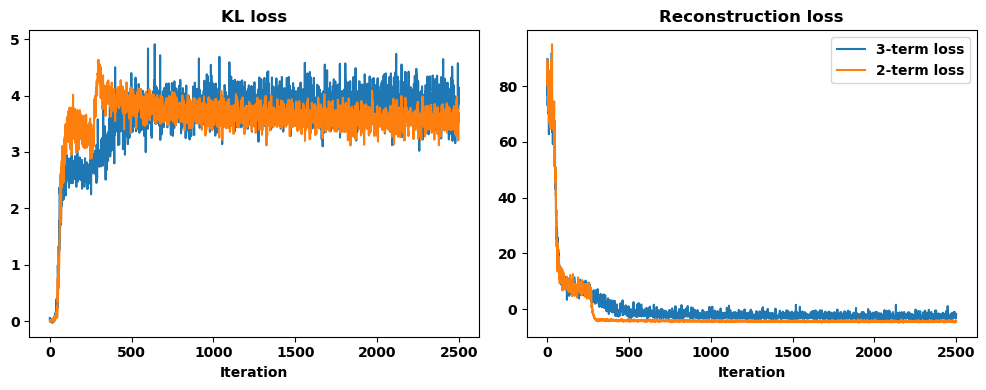

In [9]:
# Plotting!
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# KL loss
axs[0].plot(kl_1a)
axs[0].plot(kl_1b)
axs[0].set_xlabel("Iteration")
axs[0].set_title("KL loss")
# Reconstruction loss
axs[1].plot(recon_1a, label="3-term loss")
axs[1].plot(recon_1b, label="2-term loss")
axs[1].set_xlabel("Iteration")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.tight_layout()

### Plot mutual information

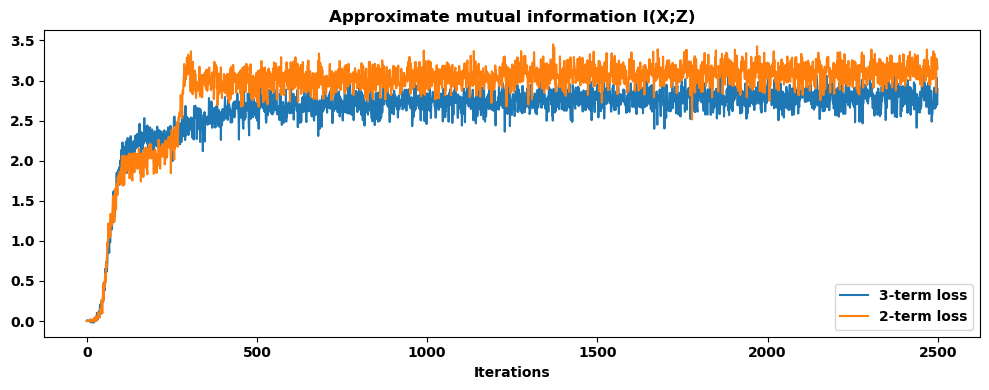

In [10]:
metrics_arr = [metrics_1a, metrics_1b]
lbls = ["3-term loss", "2-term loss"]

fig, axs = plt.subplots(1, 1, figsize=(10, 4))

for i in range(2):
    axs.plot(metrics_arr[i]['ami'], label=lbls[i])
axs.set_xlabel("Iterations")
axs.set_title("Approximate mutual information I(X;Z)")
plt.legend()
plt.tight_layout()

# Investigation 2: Compound posterior

In [11]:
cfg['ivae_loss'] = True
cfg['compound'] = True

In [12]:
ku = 40
model = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
util.get_num_parameters(model)

recon_2a, kl_2a, metrics_2a = util.train_ivae(model, optimizer, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:09<00:00,  1.97s/it]


### Plot training loss

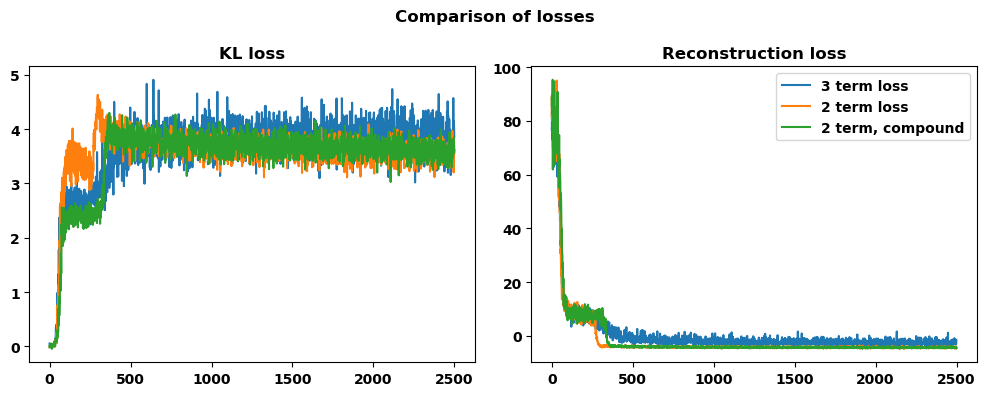

In [13]:
# Plotting!
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# KL loss
axs[0].plot(kl_1a, label="3 term loss")
axs[0].plot(kl_1b, label="2 term loss")
axs[0].plot(kl_2a, label="2 term, compound")
axs[0].set_title("KL loss")
# Reconstruction loss
axs[1].plot(recon_1a, label="3 term loss")
axs[1].plot(recon_1b, label="2 term loss")
axs[1].plot(recon_2a, label="2 term, compound")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.suptitle("Comparison of losses")
plt.tight_layout()